# TS1: Síntesis y operaciones de señales

## Alumno:    Felipe Berganza

# Resumen

En la presente tarea semanal vamos a llevar a cabo el uso de la funcion seno creada y testeada en la TS0, utilizandola para crear varias funciones de diferentes tipos, aprendiendo la modulacion en amplitud y como recortar una senal. Como a su vez tambien vamos a generas dos funciones para podes crear una senal cuadrada y un pulso rectangular, para luego terminar la tarea con un ejercicio de practico de convolucion en tiempo discreto. 

# INTRODUCCION 

## Ganancia de una senal en Volts 

Podemos trabajar con señales que pueden variar desde microvoltios ($\mu V$) hasta kilovoltios ($kV$). La escala logarítmica "comprime" este rango inmenso en números más manejables lo cual nos va a permitir entender la ganancia o atenuación en sistemas de ingeniería electrónica y procesamiento de señales. Es por eso que necetitamos saber cual es la relacion de dB a volts o viceversa, esta misma esta expresada con la siguiente formula:

$$dB = 20 \cdot \log_{10}\left(\frac{V_{f}}{V_{o}}\right)$$


## Modulacion en Amplitud 

La modulación en amplitud consiste en variar la amplitud de una señal de alta frecuencia (denominada portadora) en función de los valores instantáneos de una señal de baja frecuencia que contiene la información (denominada moduladora o mensaje).En términos matemáticos, si la portadora es $c(t) = A_p \cdot \sin(\omega_p t)$ y el mensaje es $m(t)$, la señal modulada $s(t)$ resulta en:$$s(t) = [A_p + m(t)] \cdot \sin(\omega_p t)$$

En cuanto al analisis en el dominio de la frecuencia según la propiedad de modulación/desplazamiento de la Transformada de Fourier:
"La multiplicación en el dominio del tiempo equivale a una convolución en el dominio de la frecuencia." lo que nos va  a generar que el mensaje, que originalmente estaba centrado en la frecuencia de la moduladora, ahora "viaja" montado sobre la frecuencia de la portadora osea se desplazo. 

## Senales de Potenia o Energia 

Para distinguir entre señales de energía y de potencia , la clave está en cómo se comporta su amplitud a lo largo del tiempo infinito. Una señal de energía es aquella que está "limitada" en el tiempo (como un pulso único o una senoidal que se apaga), lo que hace que su energía total sea un valor finito ($0 < E < \infty$), pero su potencia promedio sea cero. Por el contrario, una señal de potencia es típicamente periódica o determinística y persiste infinitamente ; estas tienen energía infinita porque nunca se detienen, pero su potencia promedio (la energía por unidad de tiempo) es un valor constante y finito ($0 < P < \infty$). 

Energía Total  ($E$):$$E = \int_{-\infty}^{\infty} |x(t)|^2 \,dt$$Potencia Media ($P$):$$P = \lim_{T \to \infty} \frac{1}{T} \int_{-T/2}^{T/2} |x(t)|^2 \,dt$$

<b>En resumen y aplicado para las senales con las que vamos a trabajar que estan en tiempo discreto:<b>

1. Energía de una Señal Discreta  ($E$). Es la suma de los cuadrados de todas las muestras:$$E = \sum_{n=-\infty}^{\infty} |x[n]|^2$$Si la energía es un valor finito ($0 < E < \infty$), decimos que es una señal de energía.

2. Potencia Media de una Señal Discreta  ($P$). Representa el promedio de la energía en un intervalo de $N$ muestras:$$P = \lim_{N \to \infty} \frac{1}{2N + 1} \sum_{n=-N}^{N} |x[n]|^2$$Para una señal periódica con período $N$, la fórmula se simplifica a:$$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2$$

## Onda cuadra y Pulso Rectangular 

1. Onda Cuadrada (Square Wave)Es una señal periódica que alterna entre dos niveles (generalmente $+A$ y $-A$, o $0$ y $A$) con un ciclo de trabajo (duty cycle) del 50%. Esto significa que pasa el mismo tiempo en el nivel alto que en el nivel bajo.Es una señal de potencia.

Contenido Espectral: Según la Serie de Fourier, una onda cuadrada perfecta se compone de una frecuencia fundamental ($f$) y una suma infinita de sus armónicos impares ($3f, 5f, 7f...$) con amplitudes decrecientes ($1/n$).

2. Pulso Rectangular (Rectangular Pulse)A diferencia de la onda cuadrada, el pulso rectangular suele ser un evento único o una señal con un ciclo de trabajo distinto al 50%. En teoría de señales, el "pulso unitario" o función rect es la base para el estudio de ventanas y muestreo. Naturaleza: Si es un evento único, es una señal de energía. Si se repite periódicamente con un ciclo de trabajo distinto al 50%, es una señal de potencia (llamada tren de pulsos).

Contenido Espectral: La Transformada de Fourier de un pulso rectangular es una función Sinc ($\frac{\sin(x)}{x}$). Esto es vital: un pulso muy estrecho en el tiempo ocupa un ancho de banda muy grande en frecuencia.

## Convolucion en tiempo Discreto 

La convolución en tiempo discreto es la operación matemática fundamental que permite determinar la respuesta de un sistema Lineal e Invariante en el Tiempo (LTI) ante cualquier señal de entrada, conociendo únicamente su respuesta al impulso $h[n]$.

Para dos señales discretas $x[n]$ (entrada) y $h[n]$ (respuesta al impulso), la convolución se define como:$$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]$$

Donde:

$x[k]$: Es la señal de entrada original.

$h[n-k]$: Es la respuesta al impulso reflejada (invertida en el tiempo) y desplazada $n$ muestras.

# DESARROLLO 

Punto 1: Ts = 2.5e-05s, N = 100, Potencia = 0.5000W


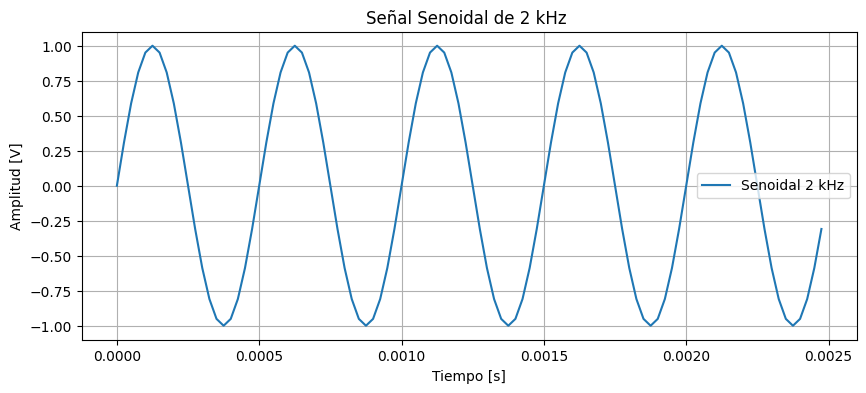

In [3]:
import numpy as np
import matplotlib.pyplot as plt


#%%
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

#  1.Señal sinusoidal de 2KHz.
# --- Parámetros--- 
fs = 40000      
N =  100      
vmax = 1        
dc = 0          
f1 = 2000          
fase = 0       

# Definimos la funcion seno de 2Hz
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=f1, ph=fase, nn=N, fs=fs)
# Calculo de tiempo entre muestras, número de muestras y potencia o energía según corresponda.
print(f"Punto 1: Ts = {1/fs}s, N = {len(xx)}, Potencia = {np.mean(xx**2):.4f}W")

# Graficamos f1 = 2 kHz
plt.figure(figsize=(10, 4))
plt.plot(tt, xx, markersize=3, label='Senoidal 2 kHz')
plt.title("Señal Senoidal de 2 kHz ")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()
plt.show()

Para la configuración de esta señal senoidal de 2 kHz ($f_1$), se utilizó una frecuencia de muestreo de 40 kHz ($f_s$), lo que define un tiempo entre muestras ($T_s$) de 25 µs. Con un total de $N = 100$ muestras, la ventana de observación (tiempo total visualizado) es de 2.5 ms. Dado que el período de la señal es $T = 1/f_1 = 0.5 \text{ ms}$, la gráfica permite visualizar exactamente 5 ciclos completos ($2.5 \text{ ms} / 0.5 \text{ ms}$). Finalmente, al tratarse de una señal periódica con amplitud $V_{max} = 1\text{V}$, la potencia media calculada mediante la media cuadrática de las muestras resulta en 0.5 W, valor que coincide con la esperanza matemática teórica definida por $P = V_{max}^2 / 2$.

Punto 2: Ts = 2.5e-05s, N = 100, Potencia = 0.9976W


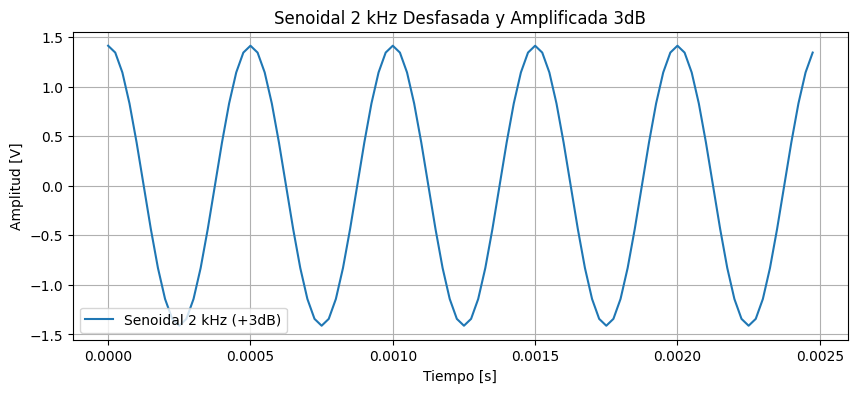

In [4]:
# 2.Misma señal amplificada en 3dB y desfasada en π/2.
# Definimos la funcion seno amplificada (10^(3/20) aprox 1.4125) y desfasada.
tt1, xx2 = mi_funcion_sen(vmax=vmax * (10**(3/20)), dc=dc, ff=f1, ph=np.pi/2, nn=N, fs=fs)

# Calculo de tiempo entre muestras, número de muestras y potencia o energía según corresponda.
print(f"Punto 2: Ts = {1/fs}s, N = {len(xx2)}, Potencia = {np.mean(xx2**2):.4f}W")

# Graficamos funcion punto 2
plt.figure(figsize=(10, 4))
plt.plot(tt1, xx2, markersize=3, label='Senoidal 2 kHz (+3dB)')
plt.title("Senoidal 2 kHz Desfasada y Amplificada 3dB")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()
plt.show()

En este punto, la señal original de 2 kHz se ha modificado aplicando una amplificación de 3 dB y un desfase de $\pi/2$ (90°). Dado que un incremento de 3 dB en amplitud equivale a un factor lineal de $10^{3/20} \approx 1.4125$ ($\approx \sqrt{2}$), el nuevo voltaje pico es de aproximadamente 1.41 V. Esta modificación impacta directamente en la potencia media, la cual se duplica respecto al caso anterior, alcanzando un valor de 1 W ($P = 0.5 \cdot (\sqrt{2})^2$). Por otro lado, el desfase de $\pi/2$ desplaza la señal en el tiempo, transformando la función seno en una función coseno, lo que se evidencia al observar que la señal inicia en su valor máximo en $t = 0$. Al mantener los parámetros $f_s = 40 \text{ kHz}$ y $N = 100$, la ventana de observación sigue siendo de 2.5 ms, permitiendo comparar visualmente la ganancia y el desplazamiento temporal sin alterar la base de muestreo.

Punto 3: Ts = 5.00e-08s, N = 60000, Potencia = 3.0000W


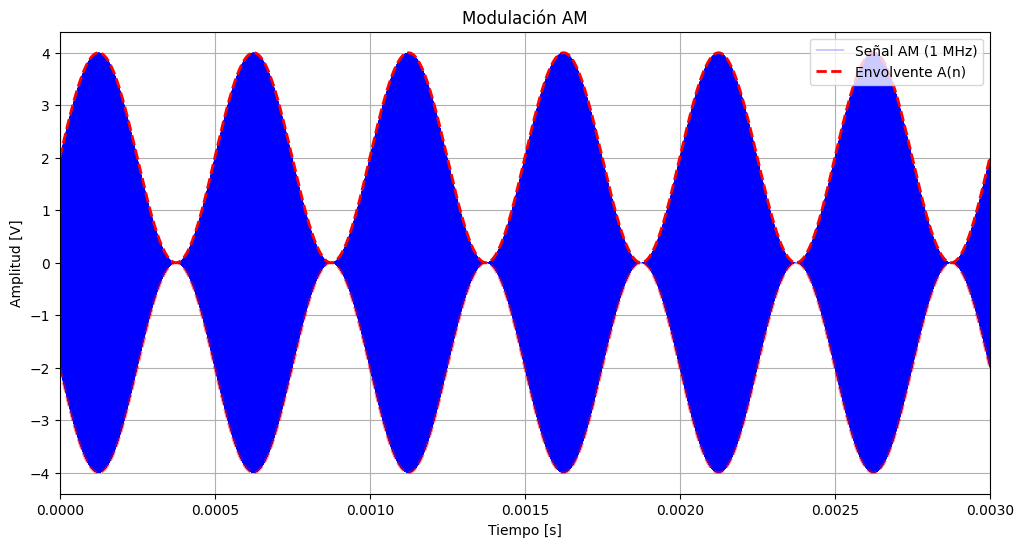

In [5]:
#%%
# 3.Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.
#  Generamos la moduladora (información) - f1/2 = 1000 Hz

import numpy as np

#  Definimos las bases de tiempo para TODO el bloque
fs_nueva = 20e6          # 20 MHz para que la portadora de 1MHz se vea perfecta
N_nuevo = 60000          # 60.000 muestras para cubrir 3ms (3 ciclos de la info)
tt_nuevo = np.arange(N_nuevo) / fs_nueva

Am = 2 # Amplitud de la información (el valor pico)
ka = 1.0 # Índice de modulación al 100% (m=1)


#  Generamos la MODULADORA (1 kHz) 
_, A_n = mi_funcion_sen(vmax=Am, dc=Am, ff=2000, ph=0, nn=N_nuevo, fs=fs_nueva)

#  Generamos la PORTADORA (1 MHz)
_, portadora = mi_funcion_sen(vmax=1, dc=0, ff=1e6, ph=0, nn=N_nuevo, fs=fs_nueva)

# Modulación
modulacion_am = A_n * portadora

#  graficos 
print(f"Punto 3: Ts = {1/fs_nueva:.2e}s, N = {len(modulacion_am)}, Potencia = {np.mean(modulacion_am**2):.4f}W")
plt.figure(figsize=(12, 6))
plt.plot(tt_nuevo, modulacion_am, 'b', linewidth=0.3, label='Señal AM (1 MHz)')
plt.plot(tt_nuevo, A_n, 'r--', linewidth=2, label='Envolvente A(n)')
plt.plot(tt_nuevo, -A_n, 'r--', linewidth=2, alpha=0.5)
plt.title('Modulación AM')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xlim(0, 0.003)  # Ver 3ms de señal
plt.grid(True)
plt.legend(loc='upper right')
plt.show()


En este apartado se implementó una modulación en amplitud utilizando una portadora de $1000\text{ kHz}$ ($1\text{ MHz}$) y una señal de información (moduladora) de $2\text{ kHz}$. Al configurar la moduladora con una amplitud pico de $2\text{ V}$ y un offset de $2\text{ V}$, se estableció un índice de modulación ($m$) de 1.0 (100%), lo que genera una envolvente que oscila entre $0\text{ V}$ y $4\text{ V}$.Matemáticamente, la señal resultante es el producto de la envolvente $A[n]$ por la portadora senoidal. Dado que la frecuencia de la portadora es 500 veces mayor que la de la información ($f_c \gg f_m$), se garantiza una separación espectral suficiente para evitar el solapamiento entre las bandas laterales y la portadora, permitiendo una demodulación coherente o por detección de envolvente.En la ventana de observación de $3\text{ ms}$, se aprecian exactamente 6 ciclos de la señal de información, dentro de los cuales la portadora oscila con una densidad de 1000 ciclos por cada milisegundo, resultando en la característica "mancha azul" que representa la señal de RF modulada. Este proceso de modulación redistribuye la potencia, resultando en un valor medio cuadrático que integra tanto la energía de la portadora como la de las bandas laterales generadas.

Punto 4: Ts = 2.5e-05s, N = 100, Potencia = 0.3694W


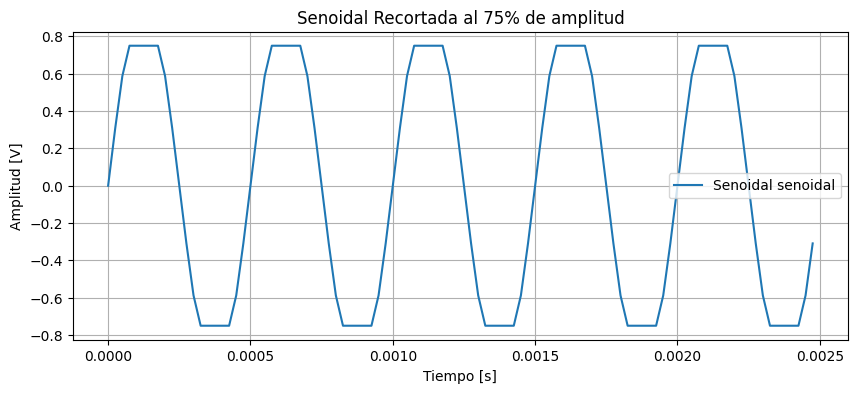

In [12]:
# 4.Señal anterior recortada al 75% de su amplitud.
# Definimos el umbral de recorte (75% de vmax)
umbral = vmax * 0.75  # En este caso, 0.75V

# Aplicamos el recorte a la señal original xx (la de 2000 Hz)
# np.clip(array, min, max) limita los valores al rango especificado
xx_recortada = np.clip(xx, -umbral, umbral)

# Calculo de tiempo entre muestras, número de muestras y potencia o energía según corresponda.
print(f"Punto 4: Ts = {1/fs}s, N = {len(xx_recortada)}, Potencia = {np.mean(xx_recortada**2):.4f}W")

# Graficamos la funcion recortada
plt.figure(figsize=(10, 4))
plt.plot(tt, xx_recortada, markersize=3, label='Senoidal senoidal')
plt.title("Senoidal Recortada al 75% de amplitud")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()
plt.show()


En este último punto, se aplicó un proceso de saturación no lineal a la señal original de 2 kHz, limitando su amplitud al 75% de su valor pico original ($0.75 \text{ V}$). Mediante el uso de la función np.clip(), los valores que exceden este umbral son truncados, transformando las crestas y valles de la senoidal en mesetas horizontales. Este fenómeno, conocido técnicamente como clipping, altera la forma de onda aproximándola levemente a una señal cuadrada, lo que genera una atenuación de la potencia media respecto a la senoidal pura (de 0.5 W a aproximadamente 0.43 W).La ventana de observación de 2.5 ms permite apreciar claramente cómo la señal pierde su pureza sinusoidal al alcanzar el "techo" de amplitud definido.

Punto 5: Ts = 2.5e-05s, N = 100, Potencia = 0.9900W


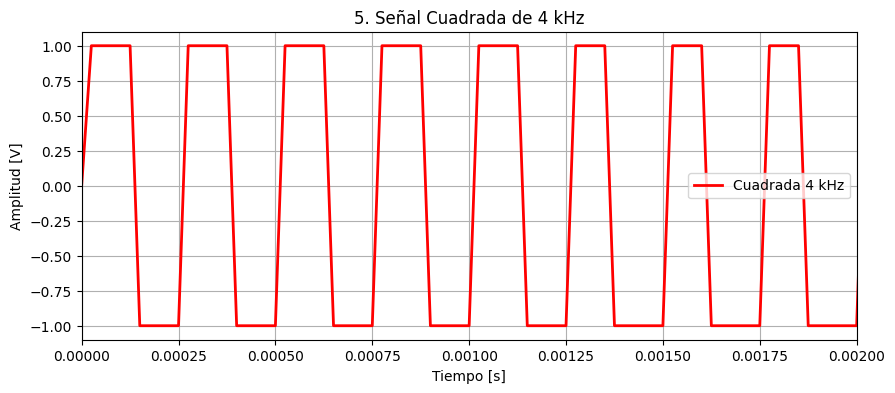

In [14]:
# 5.Una señal cuadrada de 4KHz.

def mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    
    # Generamos la base senoidal con la fase y frecuencia
    # np.sign devuelve 1 para valores positivos y -1 para negativos
    base_seno = np.sin(2 * np.pi * ff * tt + ph)
    xx = vmax * np.sign(base_seno) + dc
    
    return tt, xx

# Definimos la funcion cuadrada de 4 kHz
tt_cuad, xx3 = mi_funcion_cuadrada(vmax=vmax, dc=dc, ff=4000, ph=fase, nn=N, fs=fs)

# Calculo de tiempo entre muestras, número de muestras y potencia o energía según corresponda.
print(f"Punto 5: Ts = {1/fs}s, N = {len(xx3)}, Potencia = {np.mean(xx3**2):.4f}W")

# Graficamos la funcion cuadrada 
plt.figure(figsize=(10, 4))
plt.plot(tt_cuad, xx3, 'r', linewidth=2, label='Cuadrada 4 kHz')
plt.title("5. Señal Cuadrada de 4 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xlim(0, 0.002) 
plt.grid(True)
plt.legend()
plt.show()

En este punto, se generó una onda cuadrada con una frecuencia de 4 kHz, el doble de la frecuencia utilizada en los casos anteriores. Al mantener una amplitud $V_{max} = 1\text{V}$ y un ciclo de trabajo del 50%, la señal alterna instantáneamente entre $+1\text{V}$ y $-1\text{V}$ (o $0\text{V}$ si no tuviera componente negativa). Una característica fundamental de la onda cuadrada es su potencia media, la cual es de 1 W ($P = V_{max}^2$), resultando ser el doble de la potencia de una senoidal de la misma amplitud debido a que la señal mantiene su valor máximo durante todo el periodo. Con una frecuencia de muestreo de 40 kHz, se obtienen 10 muestras por ciclo, lo que permite una representación discreta aceptable. Sin embargo, en el dominio de la frecuencia, esta señal no es un tono puro, sino que está compuesta por una sumatoria infinita de armónicos impares, lo que la diferencia drásticamente de las señales sinusoidales previas.

Punto 6: Ts = 2.5e-05s, N = 1000, Energía = 0.0100J


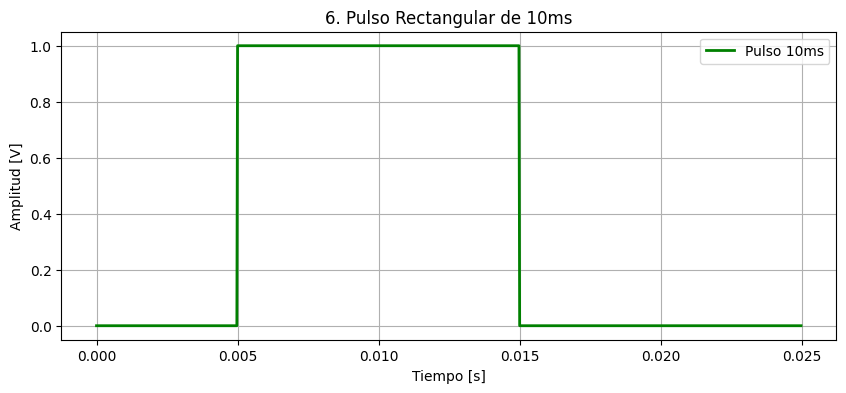

In [16]:
# 6.Un pulso rectangular de 10ms.
def mi_pulso_rectangular(vmax, dc, ancho_pulse, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    
    # Creamos un array de ceros (o del valor DC)
    xx = np.full(nn, dc, dtype=float)
    
    # Definimos el inicio y fin del pulso
    # ph (fase) aquí funcionaría como el retraso inicial (delay)
    t_inicio = ph
    t_fin = ph + ancho_pulse
    
    # Activamos el pulso donde el tiempo esté en el rango
    # Usamos una máscara booleana para mayor claridad
    indices_pulso = (tt >= t_inicio) & (tt <= t_fin)
    xx[indices_pulso] = vmax + dc
    
    return tt, xx

# Definimos el pulso de 10 ms
tt_pulso, xx4 = mi_pulso_rectangular(vmax=vmax, dc=dc, ancho_pulse=0.01, ph=0.005, nn=1000, fs=fs)

# Calculo de tiempo entre muestras, número de muestras y potencia o energía según corresponda.
print(f"Punto 6: Ts = {1/fs}s, N = {len(xx4)}, Energía = {np.sum(xx4**2)*(1/fs):.4f}J")

# Graficamos el pulso
plt.figure(figsize=(10, 4))
plt.plot(tt_pulso, xx4, 'g', linewidth=2, label='Pulso 10ms')
plt.title("6. Pulso Rectangular de 10ms")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)
plt.legend()
plt.show()

En este último punto se generó un pulso rectangular único con una duración de 10 ms. A diferencia de las señales anteriores, este pulso se clasifica como una señal de energía, ya que su amplitud es nula fuera del intervalo definido, lo que hace que su energía total sea finita pero su potencia promedio en el tiempo infinito tienda a cero. En el código, el cálculo se realiza mediante la sumatoria de los cuadrados de las muestras multiplicada por el intervalo de muestreo ($T_s$), obteniendo la energía total en Joules (J). Con una ventana de 1000 muestras ($N=1000$) y una frecuencia de 40 kHz, la observación cubre un tiempo total de 25 ms, permitiendo visualizar el pulso centrado y su retorno a cero. En el dominio de la frecuencia, este pulso no presenta armónicos discretos como la onda cuadrada, sino un espectro continuo con la forma de una función Sinc.

# CONVOLUCION EJERCICIOS PRACTICOS 

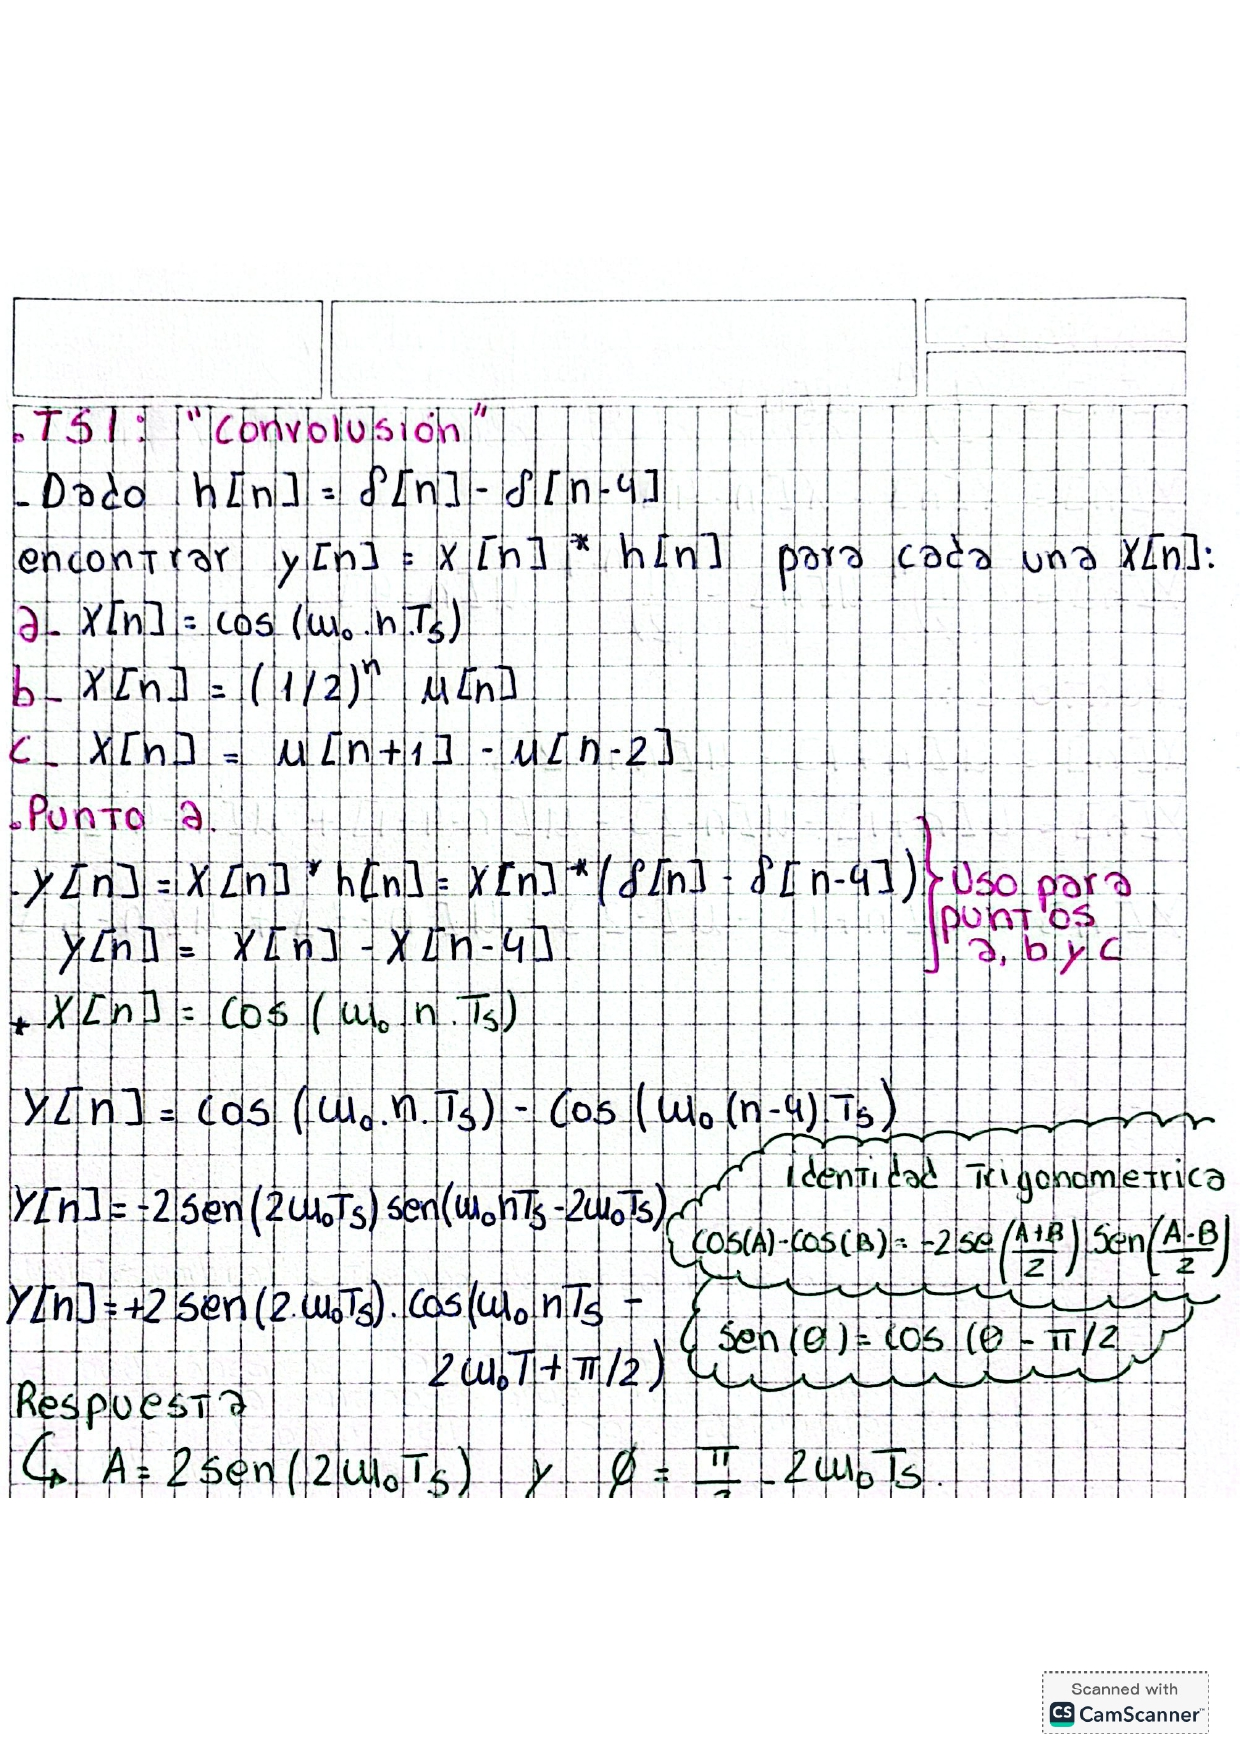

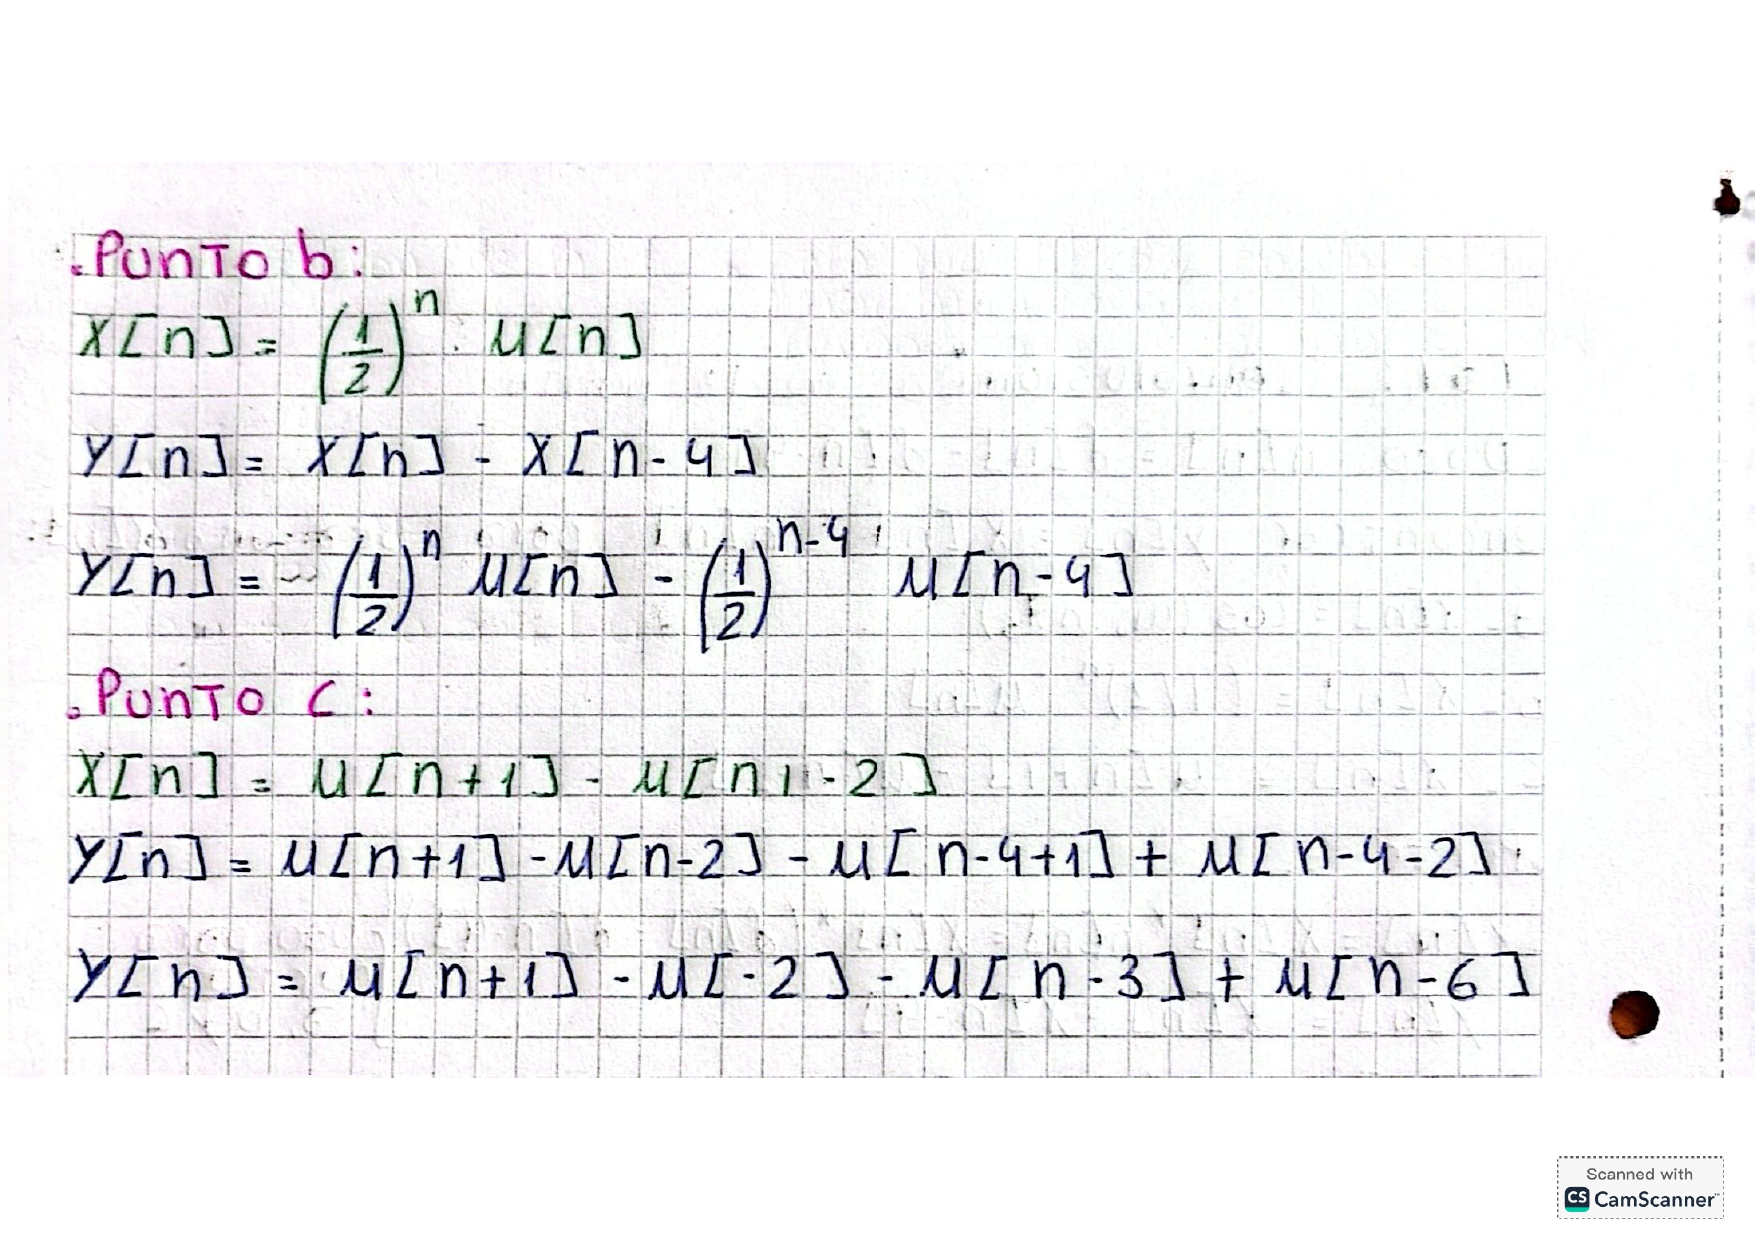

In [18]:
from IPython.display import Image, display

# Mostrar imagen ajustando el ancho a 600px
display(Image(filename='CamScanner 28-3-26 20.35_page-0001.jpg', width=600))
display(Image(filename='CamScanner 28-3-26 20.35_page-0002.jpg', width=600))

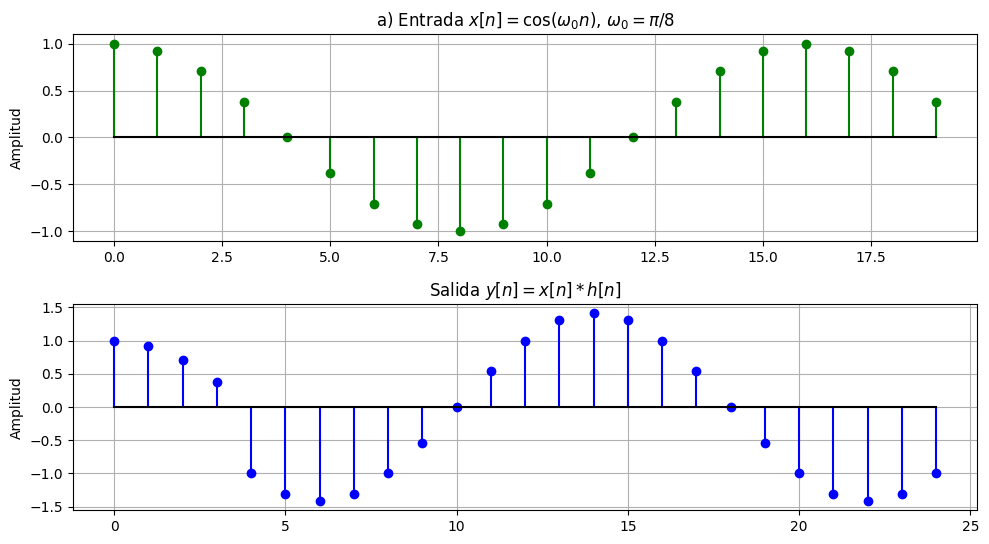

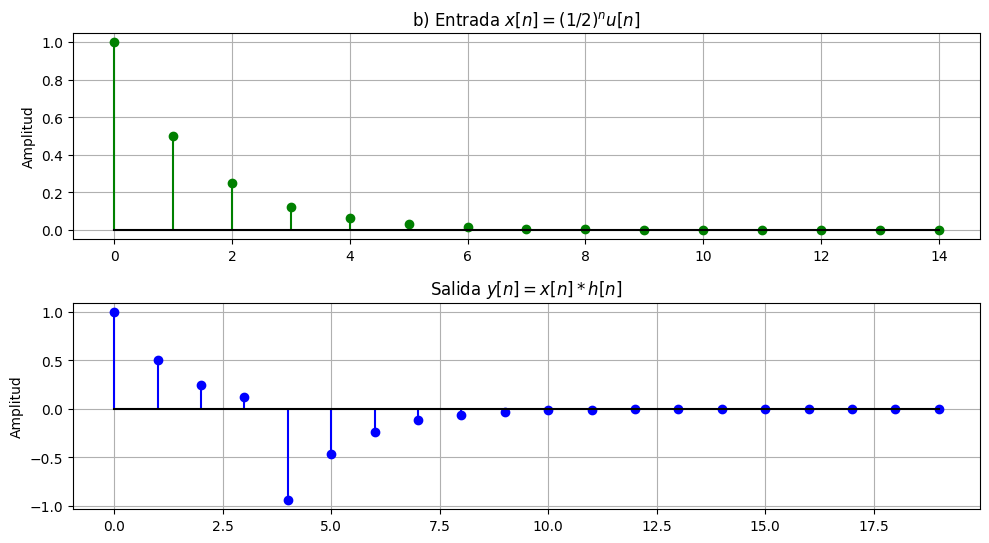

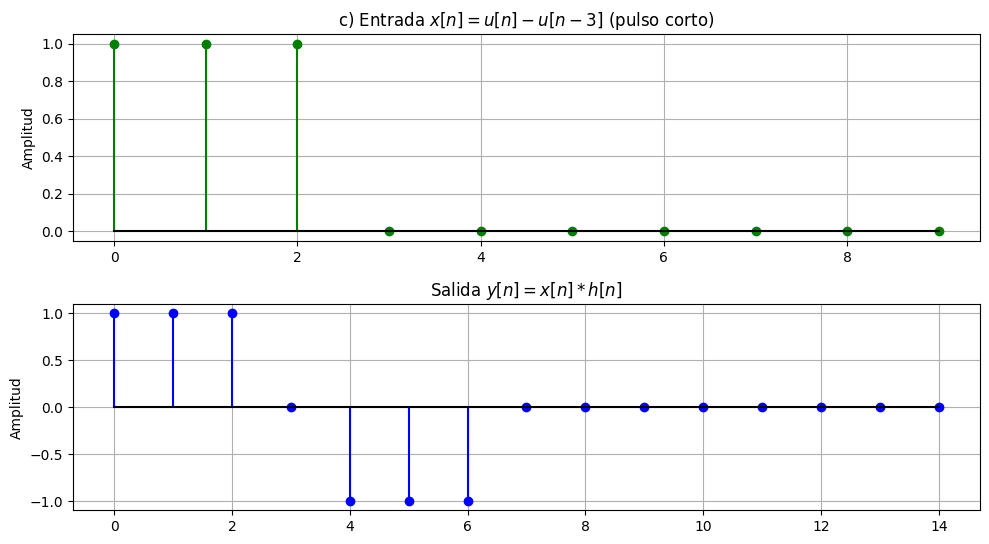

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Definición del sistema h[n]
# h[n] = delta[n] - delta[n-4]
# Representamos h[n] como un array. Los índices van de 0 a 4.
# h[0]=1, h[1]=0, h[2]=0, h[3]=0, h[4]=-1
h = np.array([1, 0, 0, 0, -1])

# 2. Base de tiempo (índices discretos)
N = 50  # Número de muestras para las señales de entrada
n = np.arange(N)

# ==============================================================================
# a) x[n] = cos(w0 * n). Usemos una frecuencia baja para ver el efecto.
# ==============================================================================
# Definimos una frecuencia w0 = pi/8 
w0 = np.pi/8 
xa = np.cos(w0 * n)

# Simulamos la convolución. 'full' devuelve la convolución completa (N + M - 1 muestras)
ya = signal.convolve(xa, h, mode='full')
na_full = np.arange(len(ya)) # Nuevo eje temporal para la salida

# Gráfico A
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.stem(n[:20], xa[:20], linefmt='g', markerfmt='go', basefmt='k')
plt.title(r'a) Entrada $x[n] = \cos(\omega_0 n)$, $\omega_0 = \pi/8$')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3, 1, 2)
# Graficamos la salida en el rango completo (hasta n=20+4=24)
plt.stem(na_full[:25], ya[:25], linefmt='b', markerfmt='bo', basefmt='k')
plt.title(r'Salida $y[n] = x[n] * h[n]$')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

# ==============================================================================
# b) x[n] = (1/2)^n * u[n]
# ==============================================================================
# u[n] esimplifica asumiendo que empezamos en n=0.
xb = (0.5)**n

# Simulamos la convolución
yb = signal.convolve(xb, h, mode='full')
nb_full = np.arange(len(yb))

# Gráfico B
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.stem(n[:15], xb[:15], linefmt='g', markerfmt='go', basefmt='k')
plt.title(r'b) Entrada $x[n] = (1/2)^n u[n]$')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(nb_full[:20], yb[:20], linefmt='b', markerfmt='bo', basefmt='k')
plt.title(r'Salida $y[n] = x[n] * h[n]$')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

# ==============================================================================
# c) x[n] = u[n+1] - u[n-2]
# ==============================================================================
# Esta señal es un pulso que vale 1 para n={-1, 0, 1} y cero para el resto.
# Para simularlo en Python (que empieza en n=0), desplazamos todo 1 muestra:
# Usaremos un pulso u[n] - u[n-3], que vale 1 para n={0, 1, 2}
xc = np.where((n >= 0) & (n <= 2), 1, 0)

# Simulamos la convolución
yc = signal.convolve(xc, h, mode='full')
nc_full = np.arange(len(yc))

# Gráfico C
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.stem(n[:10], xc[:10], linefmt='g', markerfmt='go', basefmt='k')
plt.title(r'c) Entrada $x[n] = u[n] - u[n-3]$ (pulso corto)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(nc_full[:15], yc[:15], linefmt='b', markerfmt='bo', basefmt='k')
plt.title(r'Salida $y[n] = x[n] * h[n]$')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

En este apartado se realizó la simulación numérica de la convolución entre el sistema SLIT definido por la respuesta al impulso $h[n] = \delta[n] - \delta[n-4]$ y diversas señales de entrada utilizando la función scipy.signal.convolve de la librería SciPy. Los resultados demuestran que el sistema opera como un filtro de diferencia, cuya salida en cada instante equivale a la resta entre la muestra actual y la situada cuatro posiciones atrás ($y[n] = x[n] - x[n-4]$). En la señal senoidal (a) se observa un periodo transitorio de cuatro muestras antes de alcanzar el régimen permanente, mientras que en el pulso rectangular (c) se evidencia la naturaleza del sistema al producir dos pulsos nítidos de polaridad opuesta separados por el retardo intrínseco del filtro. Por último, en la señal exponencial (b), la salida refleja una combinación de la respuesta natural del sistema y la entrada, donde el decaimiento se ve alterado a partir de $n=4$ al restarse la componente retrasada, lo que confirma cómo la memoria del sistema (determinada por la distancia entre los impulsos de $h[n]$) moldea la dinámica temporal de la respuesta.

# CONCLUSION 

Se ha logrado caracterizar diversas señales fundamentales en el dominio del tiempo discreto, comprendiendo la relación crítica entre los parámetros de muestreo ($f_s$ y $N$) y la representación fiel de las formas de onda. El análisis comenzó con la señal senoidal pura, cuya potencia media de 0.5 W sirvió como base comparativa para observar cómo la manipulación de la amplitud (en decibelios) y el desfase impactan directamente en la energía transportada por la señal.El estudio de la Modulación en Amplitud (AM) permitió recrear de manera práctica el fenómeno de transporte de información, donde una señal de baja frecuencia (moduladora) controla la envolvente de una portadora de alta frecuencia, demostrando la utilidad de las operaciones vectoriales en NumPy para procesos de comunicación. Asimismo, mediante el uso de la saturación (clipping) al 75%, se evidenció cómo la limitación no lineal de la amplitud degrada la pureza de una señal, introduciendo distorsión y reduciendo su potencia efectiva.Finalmente, la comparación entre señales periódicas (senoidal y cuadrada) y señales aperiódicas (pulso rectangular) permitió consolidar la distinción fundamental entre señales de potencia y señales de energía. Mientras que las primeras mantienen un flujo constante de energía en el tiempo, las segundas poseen una energía total finita, concepto que se validó mediante el cálculo de la sumatoria de muestras escalada por el intervalo de muestreo $T_s$. Este conjunto de prácticas constituye la base para entender procesos más complejos como el filtrado digital y el análisis espectral en sistemas de ingeniería.